# Comparativa global de modelos

Este notebook unifica la comparativa final de todos los modelos del TFG:

- Random Forest
- XGBoost
- LightGBM
- CatBoost
- Linear SVM
- TensorFlow MLP
<!-- - LSTM -->
- CNN-1D

Se sigue la misma idea de `comparativaArboles.ipynb`: entrenar cada ganador con todo el conjunto de train, medir la inferencia y comparar:

- `Latencia_ms`
- `Thruput (paq/s)`
- `Incremento RAM (MB)`
- `Porcentaje CPU`

Además se genera:

- una curva ROC conjunta de todos los modelos
- un panel de matrices de confusión

<!-- Nota metodológica original: `LSTM` se evalúa sobre secuencias temporales efectivas. -->
Nota metodológica: `CNN-1D` se evalúa en enfoque tabular, tratando cada flujo como un vector de caracteristicas con forma `(n_features, 1)`.

In [2]:
import os
import time
import numpy as np
import polars as pl
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
# from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

### Diccionario de Métricas de Evaluación

| Métrica | ¿Qué es y qué representa? (Significado Técnico) | ¿Cómo la hemos calculado? (Metodología de Código) |
| :--- | :--- | :--- |
| **F1-Score** | Métrica de eficacia predictiva. Es la media armónica entre Precisión y Sensibilidad (Recall). Representa la capacidad del modelo para detectar ataques reales minimizando las falsas alarmas, siendo la métrica ideal para tráfico de red desbalanceado. | Calculada mediante la librería `scikit-learn` (`f1_score`), cruzando las etiquetas reales del dataset de test frente a las predicciones generadas por el modelo. |
| **Latencia (ms)** | Tiempo de respuesta unitario. Representa los milisegundos físicos que tarda el sistema en procesar y clasificar un único paquete de red desde que entra al modelo hasta que sale el veredicto. | Calculada midiendo el tiempo real transcurrido (*Wall Time* mediante `time.perf_counter()`) al procesar el set de test por lotes, dividido entre el número total de paquetes procesados. |
| **Throughput (paq/s)** | Caudal o ancho de banda de procesamiento. Representa el volumen de tráfico (paquetes por segundo) que el modelo puede soportar sin generar cuellos de botella en la red. | Obtenido matemáticamente dividiendo el número total de paquetes del conjunto de test entre el tiempo físico total (*Wall Time* en segundos) que tardó en procesarlos. |
| **Incremento RAM (MB)** | Incremento de memoria residente observado durante la inferencia. Representa cuánta memoria física extra necesitó el proceso sobre su línea base al procesar los lotes del benchmark. | Monitorizando el proceso con `psutil.memory_info().rss`, restando la memoria base (antes del bucle de inferencia) al máximo RSS observado durante el procesamiento de los lotes. |
| **Porcentaje CPU** | Carga computacional global media durante la inferencia. Representa qué porcentaje de la capacidad total de CPU del servidor se utilizó mientras el modelo procesaba el conjunto de test. | Calculado como `((tiempo_cpu / tiempo_muro) / total_cpus_logicas) * 100`, usando `psutil` para medir el tiempo total de CPU del proceso y `time.perf_counter()` para el tiempo real transcurrido. |


En nuestro benchmark no estamos midiendo el entrenamiento, sino la inferencia. Durante el entrenamiento, casi todos los modelos sí intentan usar el 100% de los núcleos porque están construyendo matemáticas complejas desde cero. Pero en la inferencia, el modelo ya está construido; solo tiene que pasar los datos por la fórmula.




In [3]:
# Configuración de visualización

sns.set_style("whitegrid")

HAS_GPU = len(tf.config.list_physical_devices("GPU")) > 0
TRAIN_DEVICE = "/GPU:0" if HAS_GPU else "/CPU:0"
INFER_DEVICE = "/CPU:0"

if HAS_GPU:
    print("GPU detectada. Se entrenarán los modelos compatibles en GPU y se medirá la inferencia en CPU cuando aplique.")
else:
    print("No hay GPU disponible. Todo el notebook se ejecutará en CPU.")

tf.keras.backend.clear_session()

# def create_sequences(X, y, time_steps):
#     Xs, ys = [], []
#     for i in range(len(X) - time_steps + 1):
#         Xs.append(X[i:(i + time_steps)])
#         ys.append(y[i + time_steps - 1])
#     return np.array(Xs), np.array(ys)

def build_mlp_model(input_dim):
    model = keras.Sequential([
        keras.layers.InputLayer(input_shape=(input_dim,)),
        keras.layers.Dense(96, activation="relu"),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

# def build_lstm_model(time_steps, n_features, units, num_layers):
#     model = Sequential()
#     model.add(Input(shape=(time_steps, n_features)))
#     if num_layers == 1:
#         model.add(LSTM(units, unroll=True))
#     else:
#         model.add(LSTM(units, return_sequences=True, unroll=True))
#         model.add(Dropout(0.2))
#         model.add(LSTM(units, unroll=True))
#     model.add(Dropout(0.2))
#     model.add(Dense(1, activation="sigmoid"))
#     model.compile(optimizer="adam", loss="binary_crossentropy")
#     return model

DEFAULT_CNN_DROPOUT = 0.2

def build_cnn1d_model(n_features, n_filters, kernel_size, dense_units, dropout_rate=DEFAULT_CNN_DROPOUT):
    model = keras.Sequential([
        keras.layers.Input(shape=(n_features, 1)),
        keras.layers.Conv1D(filters=n_filters, kernel_size=kernel_size, padding="same", activation="relu"),
        keras.layers.MaxPooling1D(pool_size=2),
        keras.layers.Conv1D(filters=max(16, n_filters // 2), kernel_size=kernel_size, padding="same", activation="relu"),
        keras.layers.GlobalMaxPooling1D(),
        keras.layers.Dense(dense_units, activation="relu"),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def clone_keras_model_to_cpu(builder_fn, trained_model, *builder_args):
    with tf.device(INFER_DEVICE):
        cpu_model = builder_fn(*builder_args)
        cpu_model.set_weights(trained_model.get_weights())
    return cpu_model

def benchmark_predict(predict_fn, X_eval, model_name, block_size=2048, warmup_size=1000, repetitions=3):
    if len(X_eval) == 0:
        raise ValueError(f"{model_name}: no hay muestras para benchmark.")

    proceso = psutil.Process(os.getpid())
    warmup = X_eval[:min(warmup_size, len(X_eval))]
    _ = predict_fn(warmup)

    tiempos_muro = []
    tiempos_cpu = []
    picos_ram = []

    for _ in range(repetitions):
        cpu_ini = proceso.cpu_times() # Medición de hilo de CPU antes de la inferencia
        ram_base = proceso.memory_info().rss / (1024 * 1024)
        pico_ram_rep = ram_base

        t0 = time.perf_counter()
        for inicio in range(0, len(X_eval), block_size):
            fin = inicio + block_size
            bloque = X_eval[inicio:fin]
            _ = predict_fn(bloque)

            ram_actual = proceso.memory_info().rss / (1024 * 1024)
            if ram_actual > pico_ram_rep:
                pico_ram_rep = ram_actual

        t1 = time.perf_counter()
        cpu_fin = proceso.cpu_times() # Medición de hilo de CPU después de la inferencia

        tiempos_muro.append(t1 - t0)
        # Usamos tiempo de user y tiempo de system ya que el tiempo de user refleja el tiempo de CPU consumido por el proceso, mientras que el tiempo de system refleja el tiempo que el sistema operativo ha dedicado a ejecutar tareas en nombre del proceso, como la gestión de memoria o la entrada/salida. Al sumar ambos tiempos, obtenemos una medida más completa del consumo de CPU del proceso durante la inferencia.
        tiempos_cpu.append((cpu_fin.user - cpu_ini.user) + (cpu_fin.system - cpu_ini.system)) 
        picos_ram.append(pico_ram_rep - ram_base)

    media_muro = float(np.mean(tiempos_muro))
    media_cpu = float(np.mean(tiempos_cpu))
    pico_max_ram = float(np.max(picos_ram))
    total_nucleos = psutil.cpu_count(logical=True)

    return {
        "Modelo": model_name,
        "Latencia_ms": round((media_muro / len(X_eval)) * 1000, 5),
        "Thruput (paq/s)": round(len(X_eval) / media_muro, 0),
        "Incremento RAM (MB)": round(pico_max_ram, 2),
        "CPU efectiva (%)": round(((media_cpu / media_muro) / total_nucleos) * 100 if media_muro > 0 else 0, 1)
    }

def register_outputs(container_benchmark, container_roc, container_cm, benchmark_row, model_name, y_true, y_pred, y_score):
    benchmark_row = dict(benchmark_row)
    benchmark_row["F1_macro"] = round(float(f1_score(y_true, y_pred, average="macro")), 4)
    container_benchmark.append(benchmark_row)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    container_roc.append({"Modelo": model_name, "fpr": fpr, "tpr": tpr, "auc": roc_auc})
    container_cm.append({"Modelo": model_name, "cm": confusion_matrix(y_true, y_pred)})
    print(f"  -> {model_name}: F1={benchmark_row['F1_macro']:.4f} | AUC={roc_auc:.4f} | Acc={accuracy_score(y_true, y_pred):.4f}")


GPU detectada. Se entrenarán los modelos compatibles en GPU y se medirá la inferencia en CPU cuando aplique.


Analogía del Restaurante

Imagina que vas a un restaurante y quieres saber el tiempo total que han trabajado para ti para preparar tu plato:

    Tiempo user: Es el tiempo que el cocinero (tu modelo de Machine Learning) pasa cortando verduras y cocinando la carne.

    Tiempo system: Es el tiempo que el camarero (el Sistema Operativo) pasa yendo a la despensa a buscar ingredientes (pedir RAM) y llevándote el plato a la mesa.

La fórmula completa:
(Tiempo del Cocinero final - Tiempo del Cocinero inicial) + (Tiempo del Camarero final - Tiempo del Camarero inicial)

In [5]:
# ==========================================
# 1. CARGA DE DATOS
# ==========================================

path_train = "../../DATASETS/dataSets_Reducidos/nusw-nb15/datos_train_NUSW_redux.csv"
path_test  = "../../DATASETS/dataSets_Reducidos/nusw-nb15/datos_test_NUSW_redux.csv"
TARGET_COL = "attack_cat"

df_train = pl.read_csv(path_train)
df_test  = pl.read_csv(path_test)

y_train = (
    df_train.select(
        pl.when(pl.col(TARGET_COL).str.strip_chars() == "Normal")
        .then(1)
        .otherwise(-1)
        .alias("label")
    )
    .to_series()
    .cast(pl.Int8)
)

y_test = (
    df_test.select(
        pl.when(pl.col(TARGET_COL).str.strip_chars() == "Normal")
        .then(1)
        .otherwise(-1)
        .alias("label")
    )
    .to_series()
    .cast(pl.Int8)
)

x_train = df_train.drop(TARGET_COL)
x_test  = df_test.drop(TARGET_COL)

X_full_train = x_train.to_numpy()
X_test_np = x_test.to_numpy()
y_full_train = y_train.to_numpy()
y_test_np = y_test.to_numpy()

y_full_train_01 = ((y_full_train + 1) // 2).astype(np.int8)
y_test_np01 = ((y_test_np + 1) // 2).astype(np.int8)

print(f"Train: {X_full_train.shape} | Test: {X_test_np.shape}")
print("Tras convertir -1/1 a 0/1, la clase 0 corresponde a Ataque y la clase 1 a Normal.")

# ==========================================
# 2. CONFIGURACIÓN DE LOS GANADORES
# ==========================================

# Árboles: se respetan los modelos usados en comparativaArboles.ipynb
RF_CONFIG = {"n_estimators": 50, "max_depth": 23}
XGB_CONFIG = {"n_estimators": 200, "max_depth": 11, "learning_rate": 0.1}
LGBM_CONFIG = {"n_estimators": 100, "num_leaves": 145, "max_depth": 12, "learning_rate": 0.1}
CATBOOST_CONFIG = {"iterations": 500, "depth": 10, "learning_rate": 0.1}

# Modelos individuales: se respetan los ganadores usados en las celdas finales de benchmark/ROC
SVM_C = 0.000187
MLP_INPUT_DIM = X_full_train.shape[1]
# LSTM_CONFIG = {"ts": 10, "u": 32, "l": 1}
CNN1D_CONFIG = {"nf": 64, "k": 5, "d": 48}


Train: (175341, 12) | Test: (82332, 12)
Tras convertir -1/1 a 0/1, la clase 0 corresponde a Ataque y la clase 1 a Normal.


In [6]:
# ==========================================
# 3. ENTRENAMIENTO, BENCHMARK Y MÉTRICAS
# ==========================================

benchmark_rows = []
roc_payloads = []
cm_payloads = []

X_test_np_arr = np.array(X_test_np)

print("Entrenando y evaluando Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=RF_CONFIG["n_estimators"],
    max_depth=RF_CONFIG["max_depth"],
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_full_train, y_full_train_01)
rf_predict = lambda X: np.asarray(rf_model.predict(X)).astype(np.int8).ravel()
rf_score = lambda X: rf_model.predict_proba(X)[:, 1]
rf_benchmark = benchmark_predict(rf_predict, X_test_np_arr, "Random Forest", block_size=2048, warmup_size=1000)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, rf_benchmark, "Random Forest", y_test_np01, rf_predict(X_test_np_arr), rf_score(X_test_np_arr))

# ==========================================

print("\nEntrenando y evaluando XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=XGB_CONFIG["n_estimators"],
    max_depth=XGB_CONFIG["max_depth"],
    learning_rate=XGB_CONFIG["learning_rate"],
    tree_method="hist",
    device="cuda" if HAS_GPU else "cpu",
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_full_train, y_full_train_01)
xgb_model.set_params(device="cpu")
xgb_predict = lambda X: np.asarray(xgb_model.predict(X)).astype(np.int8).ravel()
xgb_score = lambda X: xgb_model.predict_proba(X)[:, 1]
xgb_benchmark = benchmark_predict(xgb_predict, X_test_np_arr, "XGBoost", block_size=2048, warmup_size=1000)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, xgb_benchmark, "XGBoost", y_test_np01, xgb_predict(X_test_np_arr), xgb_score(X_test_np_arr))

# ==========================================

print("\nEntrenando y evaluando LightGBM...")
lgbm_model = LGBMClassifier(
    n_estimators=LGBM_CONFIG["n_estimators"],
    num_leaves=LGBM_CONFIG["num_leaves"],
    max_depth=LGBM_CONFIG["max_depth"],
    learning_rate=LGBM_CONFIG["learning_rate"],
    device_type="gpu" if HAS_GPU else "cpu",
    n_jobs=-1,
    random_state=42,
    verbosity=-1
)
lgbm_model.fit(X_full_train, y_full_train_01)
lgbm_model.set_params(device_type="cpu")
lgbm_predict = lambda X: np.asarray(lgbm_model.predict(X)).astype(np.int8).ravel()
lgbm_score = lambda X: lgbm_model.predict_proba(X)[:, 1]
lgbm_benchmark = benchmark_predict(lgbm_predict, X_test_np_arr, "LightGBM", block_size=2048, warmup_size=1000)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, lgbm_benchmark, "LightGBM", y_test_np01, lgbm_predict(X_test_np_arr), lgbm_score(X_test_np_arr))

# ==========================================
print("\nEntrenando y evaluando CatBoost...")
cat_model = CatBoostClassifier(
    iterations=CATBOOST_CONFIG["iterations"],
    depth=CATBOOST_CONFIG["depth"],
    learning_rate=CATBOOST_CONFIG["learning_rate"],
    random_seed=42,
    logging_level="Silent",
    task_type="GPU" if HAS_GPU else "CPU"
)
cat_model.fit(X_full_train, y_full_train_01)
cat_predict = lambda X: np.asarray(cat_model.predict(X, task_type="CPU")).astype(np.int8).ravel()
cat_score = lambda X: cat_model.predict_proba(X, task_type="CPU")[:, 1]
cat_benchmark = benchmark_predict(cat_predict, X_test_np_arr, "CatBoost", block_size=2048, warmup_size=1000)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, cat_benchmark, "CatBoost", y_test_np01, cat_predict(X_test_np_arr), cat_score(X_test_np_arr))

Entrenando y evaluando Random Forest...
  -> Random Forest: F1=0.8606 | AUC=0.9742 | Acc=0.8665

Entrenando y evaluando XGBoost...
  -> XGBoost: F1=0.8579 | AUC=0.9777 | Acc=0.8641

Entrenando y evaluando LightGBM...


/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

  -> LightGBM: F1=0.8592 | AUC=0.9791 | Acc=0.8655

Entrenando y evaluando CatBoost...


  -> CatBoost: F1=0.8570 | AUC=0.9771 | Acc=0.8634


In [8]:
# ==========================================

print("\nEntrenando y evaluando Linear SVM...")
svm_model = make_pipeline(
    StandardScaler(),
    LinearSVC(C=SVM_C, dual=False, random_state=42, max_iter=2000)
)
svm_model.fit(X_full_train, y_full_train_01)
svm_predict = lambda X: np.asarray(svm_model.predict(X)).astype(np.int8).ravel()
svm_score = lambda X: svm_model.decision_function(X)
svm_benchmark = benchmark_predict(svm_predict, X_test_np_arr, "Linear SVM", block_size=2048, warmup_size=1000)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, svm_benchmark, "Linear SVM", y_test_np01, svm_predict(X_test_np_arr), svm_score(X_test_np_arr))

# ==========================================

print("\nEntrenando y evaluando TensorFlow MLP...")
tf.keras.backend.clear_session()
mlp_scaler = StandardScaler()
X_train_scaled_mlp = mlp_scaler.fit_transform(X_full_train)
X_test_scaled_mlp = mlp_scaler.transform(X_test_np_arr)
with tf.device(INFER_DEVICE):
    mlp_model = build_mlp_model(MLP_INPUT_DIM)
    mlp_early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    mlp_model.fit(
        X_train_scaled_mlp,
        y_full_train_01,
        validation_split=0.1,
        epochs=40,
        batch_size=2048,
        callbacks=[mlp_early],
        verbose=0
    )
mlp_model_cpu = clone_keras_model_to_cpu(build_mlp_model, mlp_model, MLP_INPUT_DIM)
def mlp_predict_labels(X):
    with tf.device(INFER_DEVICE):
        y_prob = mlp_model_cpu.predict(X, batch_size=4096, verbose=0).ravel()
    return (y_prob > 0.5).astype(np.int8)
def mlp_predict_scores(X):
    with tf.device(INFER_DEVICE):
        return mlp_model_cpu.predict(X, batch_size=4096, verbose=0).ravel()
mlp_benchmark = benchmark_predict(mlp_predict_labels, X_test_scaled_mlp, "TensorFlow MLP", block_size=4096, warmup_size=1024)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, mlp_benchmark, "TensorFlow MLP", y_test_np01, mlp_predict_labels(X_test_scaled_mlp), mlp_predict_scores(X_test_scaled_mlp))

# ==========================================

# print("\nEntrenando y evaluando LSTM...")
# tf.keras.backend.clear_session()
# lstm_scaler = StandardScaler()
# X_train_scaled_lstm = lstm_scaler.fit_transform(X_full_train)
# X_test_scaled_lstm = lstm_scaler.transform(X_test_np_arr)
# X_train_seq_lstm, y_train_seq_lstm = create_sequences(X_train_scaled_lstm, y_full_train_01, LSTM_CONFIG["ts"])
# X_test_seq_lstm, y_test_seq_lstm = create_sequences(X_test_scaled_lstm, y_test_np01, LSTM_CONFIG["ts"])
# with tf.device(TRAIN_DEVICE):
#     lstm_model = build_lstm_model(LSTM_CONFIG["ts"], X_train_seq_lstm.shape[2], LSTM_CONFIG["u"], LSTM_CONFIG["l"])
#     lstm_early = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
#     lstm_model.fit(
#         X_train_seq_lstm,
#         y_train_seq_lstm,
#         validation_split=0.1,
#         epochs=20,
#         batch_size=1024,
#         callbacks=[lstm_early],
#         verbose=0
#     )
# lstm_model_cpu = clone_keras_model_to_cpu(build_lstm_model, lstm_model, LSTM_CONFIG["ts"], X_train_seq_lstm.shape[2], LSTM_CONFIG["u"], LSTM_CONFIG["l"])
# def lstm_predict_labels(X):
#     with tf.device(INFER_DEVICE):
#         y_prob = lstm_model_cpu.predict(X, batch_size=1024, verbose=0).ravel()
#     return (y_prob > 0.5).astype(np.int8)
# def lstm_predict_scores(X):
#     with tf.device(INFER_DEVICE):
#         return lstm_model_cpu.predict(X, batch_size=1024, verbose=0).ravel()
# lstm_benchmark = benchmark_predict(lstm_predict_labels, X_test_seq_lstm, "LSTM", block_size=2048, warmup_size=512)
# register_outputs(benchmark_rows, roc_payloads, cm_payloads, lstm_benchmark, "LSTM", y_test_seq_lstm, lstm_predict_labels(X_test_seq_lstm), lstm_predict_scores(X_test_seq_lstm))

# ==========================================

print("\nEntrenando y evaluando CNN-1D...")
tf.keras.backend.clear_session()
cnn_scaler = MinMaxScaler()
X_train_scaled_cnn = cnn_scaler.fit_transform(X_full_train)
X_test_scaled_cnn = cnn_scaler.transform(X_test_np_arr)
X_train_tabular_cnn = X_train_scaled_cnn.reshape(X_train_scaled_cnn.shape[0], X_train_scaled_cnn.shape[1], 1)
X_test_tabular_cnn = X_test_scaled_cnn.reshape(X_test_scaled_cnn.shape[0], X_test_scaled_cnn.shape[1], 1)
with tf.device(INFER_DEVICE):
    cnn_model = build_cnn1d_model(X_train_tabular_cnn.shape[1], CNN1D_CONFIG["nf"], CNN1D_CONFIG["k"], CNN1D_CONFIG["d"])
    cnn_early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    cnn_model.fit(
        X_train_tabular_cnn,
        y_full_train_01,
        validation_split=0.1,
        epochs=20,
        batch_size=1024,
        callbacks=[cnn_early],
        verbose=0
    )
cnn_model_cpu = clone_keras_model_to_cpu(build_cnn1d_model, cnn_model, X_train_tabular_cnn.shape[1], CNN1D_CONFIG["nf"], CNN1D_CONFIG["k"], CNN1D_CONFIG["d"])
def cnn_predict_labels(X):
    with tf.device(INFER_DEVICE):
        y_prob = cnn_model_cpu.predict(X, batch_size=1024, verbose=0).ravel()
    return (y_prob > 0.5).astype(np.int8)
def cnn_predict_scores(X):
    with tf.device(INFER_DEVICE):
        return cnn_model_cpu.predict(X, batch_size=1024, verbose=0).ravel()
cnn_benchmark = benchmark_predict(cnn_predict_labels, X_test_tabular_cnn, "CNN-1D", block_size=2048, warmup_size=512)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, cnn_benchmark, "CNN-1D", y_test_np01, cnn_predict_labels(X_test_tabular_cnn), cnn_predict_scores(X_test_tabular_cnn))



Entrenando y evaluando Linear SVM...
  -> Linear SVM: F1=0.7092 | AUC=0.7492 | Acc=0.7361

Entrenando y evaluando TensorFlow MLP...


/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
W0000 00:00:1777400167.143508 2101901 platform_util.cc:146] Allowed device set contains 4 devices, but platform only sees 1
I0000 00:00:1777400167.152809 2101901 service.cc:153] XLA service 0x7f3eac6399a0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777400167.152829 2101901 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1777400167.479454 2101901 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  -> TensorFlow MLP: F1=0.7862 | AUC=0.9546 | Acc=0.8035

Entrenando y evaluando CNN-1D...
  -> CNN-1D: F1=0.7665 | AUC=0.9472 | Acc=0.7878



                TABLA GLOBAL DE RENDIMIENTO Y F1
shape: (8, 6)
┌────────────────┬─────────────┬─────────────────┬────────────────┬──────────────────┬──────────┐
│ Modelo         ┆ Latencia_ms ┆ Thruput (paq/s) ┆ Incremento RAM ┆ CPU efectiva (%) ┆ F1_macro │
│ ---            ┆ ---         ┆ ---             ┆ (MB)           ┆ ---              ┆ ---      │
│ str            ┆ f64         ┆ f64             ┆ ---            ┆ f64              ┆ f64      │
│                ┆             ┆                 ┆ f64            ┆                  ┆          │
╞════════════════╪═════════════╪═════════════════╪════════════════╪══════════════════╪══════════╡
│ Linear SVM     ┆ 0.00014     ┆ 7.315991e6      ┆ 0.09           ┆ 0.9              ┆ 0.7092   │
│ Linear SVM     ┆ 0.00014     ┆ 7.341021e6      ┆ 0.0            ┆ 0.9              ┆ 0.7092   │
│ LightGBM       ┆ 0.00064     ┆ 1.551954e6      ┆ 0.13           ┆ 100.5            ┆ 0.8592   │
│ XGBoost        ┆ 0.00067     ┆ 1.492419e6      ┆ 0.0

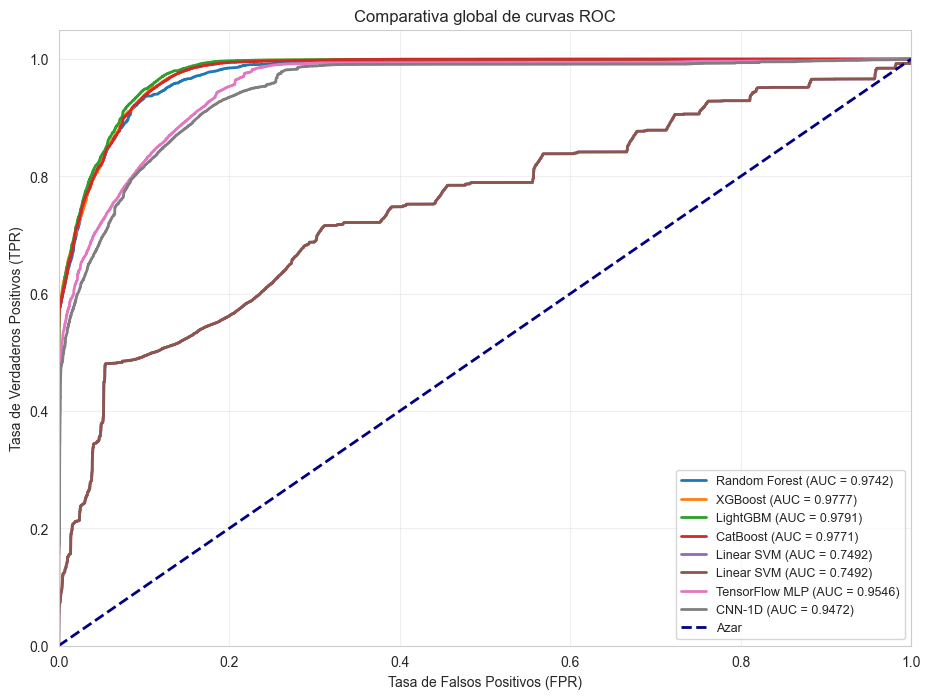

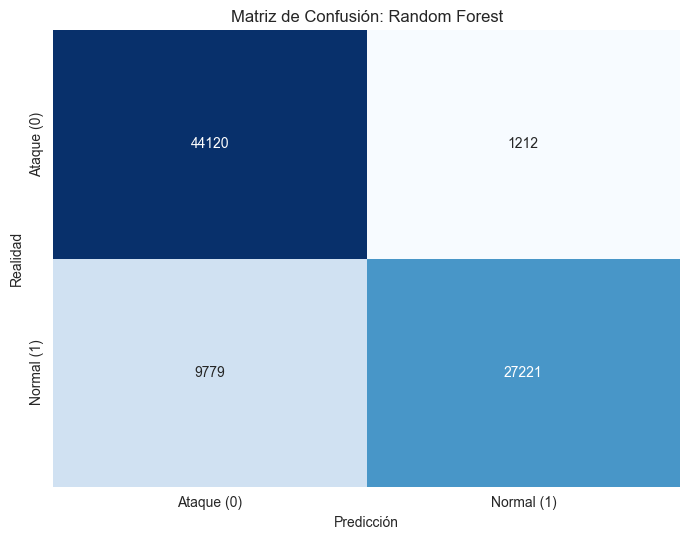

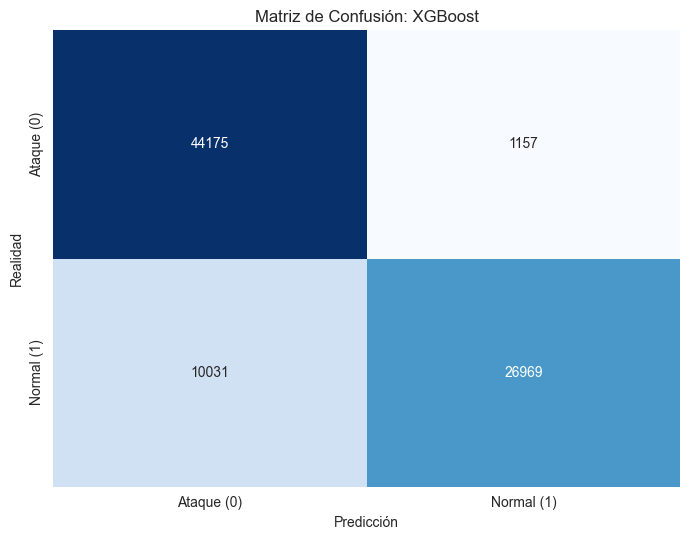

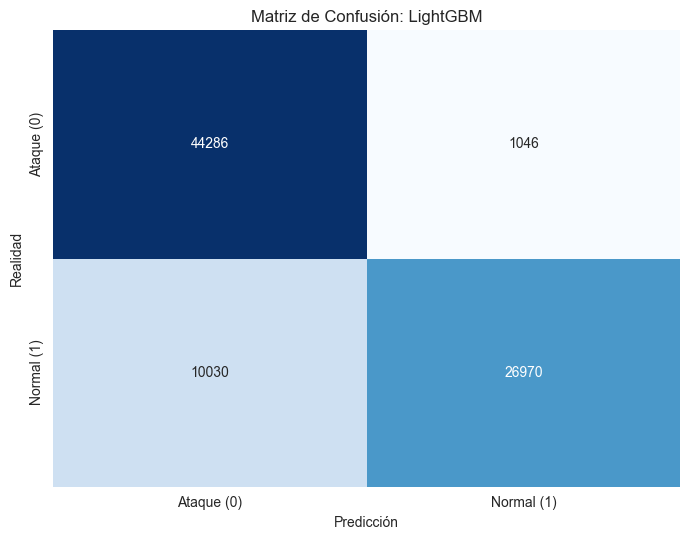

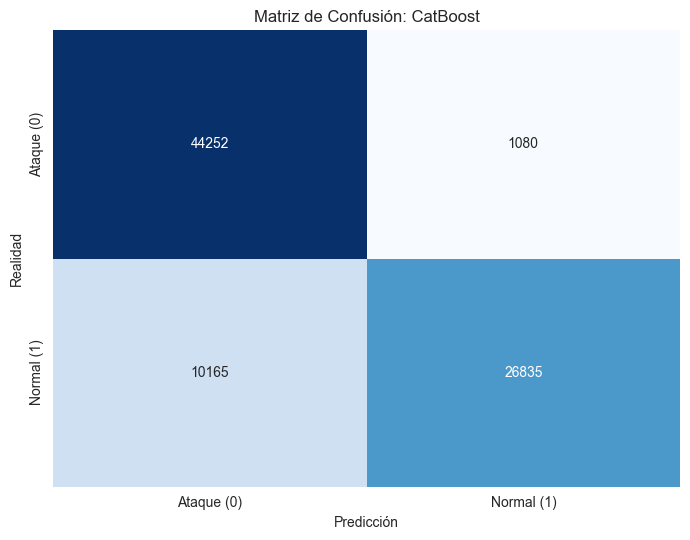

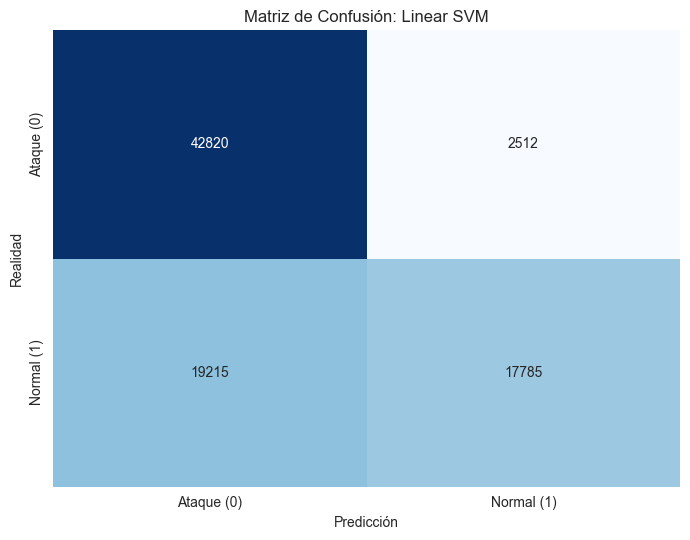

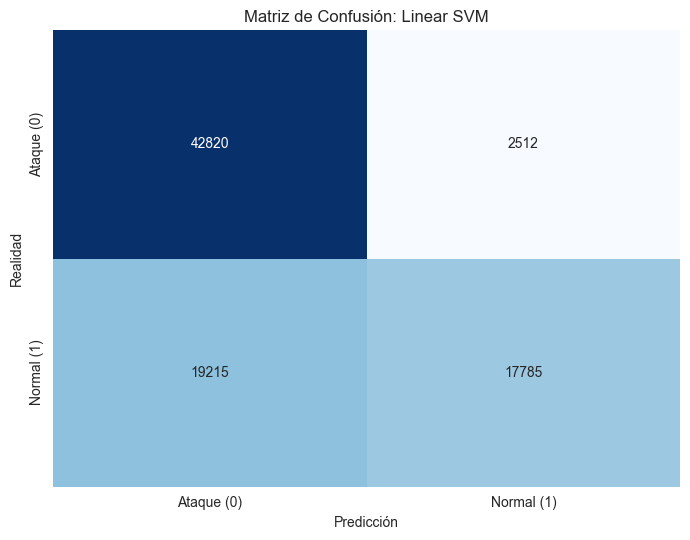

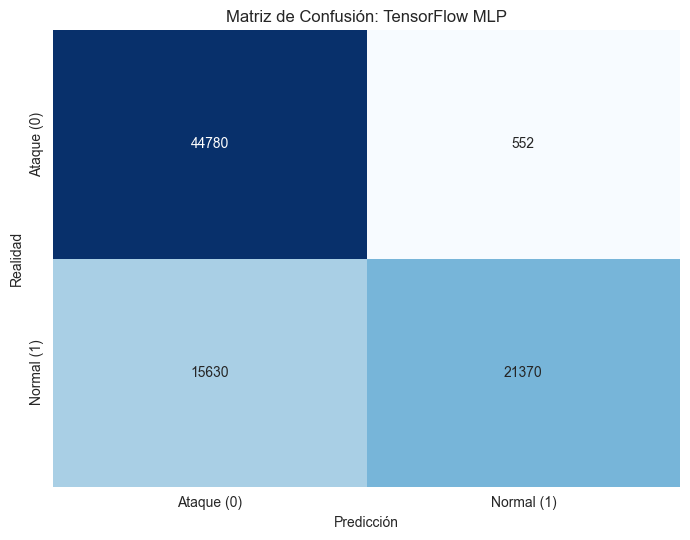

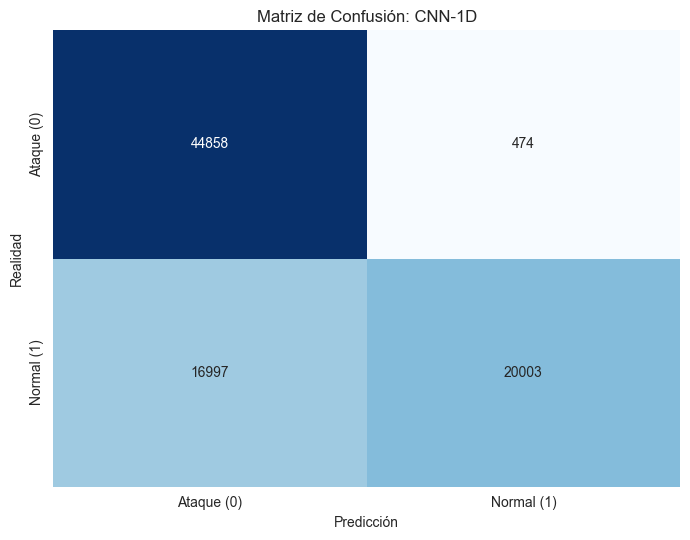

In [9]:

df_benchmark = pl.DataFrame(benchmark_rows).sort("Latencia_ms")
print("\n" + "=" * 95)
print("                TABLA GLOBAL DE RENDIMIENTO Y F1")
print("=" * 95)
print(df_benchmark)

plt.figure(figsize=(11, 8))
for payload in roc_payloads:
    plt.plot(payload["fpr"], payload["tpr"], lw=2, label=f"{payload['Modelo']} (AUC = {payload['auc']:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Azar")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Comparativa global de curvas ROC")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.show()

for payload in cm_payloads:
    fig, ax = plt.subplots(figsize=(7, 5.5))
    sns.heatmap(
        payload["cm"],
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["Ataque (0)", "Normal (1)"],
        yticklabels=["Ataque (0)", "Normal (1)"]
    )
    ax.set_title(f"Matriz de Confusión: {payload['Modelo']}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Realidad")
    plt.tight_layout()
    plt.show()